# UX Frustration Recognition Experiment

In [1]:
%matplotlib widget
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
import joblib

from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.metrics import balanced_accuracy_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

STD_BY_SUBJ = False
std_suffix = ".stdsubj" if STD_BY_SUBJ else ".stdtask"
std_models = "StdSubject" if STD_BY_SUBJ else "StdTask"

BASE_PATH = "../../experiment-data"
LABELS_SEPARATOR = ","
LABELS_FILENAME = "labels.csv"
FEATURES_SEPARATOR = ";"
FEATURES_DIRECTORY = f"{BASE_PATH}/extracted-features"
FEATURES_FILENAME = f"{FEATURES_DIRECTORY}/all_features{std_suffix}.csv"
MODELS_DATE = "20251012"
MODELS_PATH = f"Results_{std_models}/{MODELS_DATE}"
RESULTS_SEPARATOR = ","
RESULTS_DIRECTORY = f"{BASE_PATH}/results"
BIN_LABELS = ["NoStress", "Stress"]
TER_LABELS = ["Relaxed", "Stress", "RealStress"]
QAD_LABELS = ["Relaxed", "Stress", "RealStress", "Amused"]
DEBUG = True
FLOAT_TYPE = np.float32

STRESS_TASKS = ["Baseline", "AmusementClip", "StressClip"]
FRUSTRATION_TASKS = ["EmoReset", "FormL", "FormM"]

### Import labels and dataset

In [2]:
labels = pd.read_csv(f"{BASE_PATH}/{LABELS_FILENAME}", sep=LABELS_SEPARATOR, header=0, index_col=0).dropna()
display(labels)

,binary-stress,affect3-class,affect4-class
subject/task,,,
01-AmusementClip,0,0,3
01-Baseline,0,0,0
01-EmoReset,0,0,0
01-FormL,1,2,1
01-FormM,1,2,1
...,...,...,...
21-Baseline,0,0,0
21-EmoReset,0,0,0
21-FormL,0,0,0


In [3]:
X = pd.read_csv(f"{FEATURES_FILENAME}", sep=FEATURES_SEPARATOR, header=0, index_col=0)
display(X)
for col in X.columns:
    X[col] = X[col].astype(FLOAT_TYPE)
display(X)


,meanHR,minHR,maxHR,sdHR,modeHR,nNN,meanNN,SDSD,CVNN,SDNN,...,min_scl,mean_scl,sd_scl,nSCR,aucSCR,meanAmpSCR,maxAmpSCR,meanRespSCR,sumAmpSCR,sumRespSCR
01-Baseline,67.938927,4.439306,99.096774,16.084483,94.657468,52.500000,1126.860119,1748.125453,1273.147961,1.129819,...,-0.760118,0.004440,0.990295,2.000000,-54.317275,0.610357,3.466212,0.830078,1.220715,1.245117
01-AmusementClip,68.058689,8.439560,83.027027,11.425651,74.587467,60.000000,993.598090,1046.284623,725.264597,0.729938,...,-1.047913,-0.000974,0.994654,2.000000,10.771605,0.189199,0.682391,3.294271,0.378399,6.588542
01-StressClip,69.354556,8.439560,87.771429,11.111625,79.331868,63.666667,937.397742,777.753528,553.581066,0.590551,...,-1.015111,0.001272,0.985412,1.666667,-11.291831,0.223363,0.461515,1.066406,0.372272,1.777344
01-EmoReset,67.862835,4.633484,78.769231,12.163410,74.135747,55.000000,1082.741477,1813.005039,1258.505426,1.162332,...,-1.020609,0.000963,0.996866,2.000000,-7.055041,0.166580,0.805823,0.777995,0.333160,1.555990
01-FormL,72.740026,10.072131,153.600000,12.343391,143.527869,66.800000,887.443862,642.268992,458.345263,0.516478,...,-1.359052,0.007178,0.948213,1.800000,-1.794321,1.011426,3.681678,13.962674,1.820567,25.132812
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21-StressClip,79.547845,19.948052,87.771429,7.850818,67.823377,72.988384,780.092593,383.750433,272.192135,0.348923,...,-1.233190,0.001964,0.950427,0.540655,-2.007692,3.065072,3.065072,7.656250,1.657146,4.139388
21-EmoReset,82.437562,13.963636,90.352941,5.186123,76.389305,80.655325,740.546875,319.267953,226.755158,0.306200,...,-1.474851,0.004269,0.937666,3.548834,-17.690004,0.742909,2.196171,2.228338,2.636461,7.908003
21-FormL,79.716174,11.861004,170.666667,8.736983,158.805663,77.612075,771.702776,371.389631,262.132710,0.339681,...,-1.284004,0.001639,0.987437,2.727581,-9.724188,0.365968,1.106248,9.481534,0.998207,25.861651
21-FormM,82.096186,28.444444,93.090909,4.388562,64.646465,81.368452,734.986034,102.934253,85.176432,0.115889,...,-1.582827,0.005257,0.804585,5.757917,-79.122038,1.287057,3.148032,1.746962,7.410764,9.529447


,meanHR,minHR,maxHR,sdHR,modeHR,nNN,meanNN,SDSD,CVNN,SDNN,...,min_scl,mean_scl,sd_scl,nSCR,aucSCR,meanAmpSCR,maxAmpSCR,meanRespSCR,sumAmpSCR,sumRespSCR
01-Baseline,67.938927,4.439306,99.096771,16.084482,94.657471,52.500000,1126.860107,1748.125488,1273.147949,1.129819,...,-0.760118,0.004440,0.990295,2.000000,-54.317276,0.610357,3.466212,0.830078,1.220715,1.245117
01-AmusementClip,68.058685,8.439561,83.027023,11.425651,74.587463,60.000000,993.598083,1046.284668,725.264587,0.729938,...,-1.047913,-0.000974,0.994654,2.000000,10.771605,0.189199,0.682391,3.294271,0.378399,6.588542
01-StressClip,69.354553,8.439561,87.771431,11.111626,79.331871,63.666668,937.397766,777.753540,553.581055,0.590551,...,-1.015111,0.001272,0.985412,1.666667,-11.291831,0.223363,0.461515,1.066406,0.372272,1.777344
01-EmoReset,67.862831,4.633484,78.769234,12.163410,74.135750,55.000000,1082.741455,1813.005005,1258.505371,1.162332,...,-1.020609,0.000963,0.996866,2.000000,-7.055041,0.166580,0.805823,0.777995,0.333160,1.555990
01-FormL,72.740028,10.072131,153.600006,12.343390,143.527863,66.800003,887.443848,642.268982,458.345276,0.516478,...,-1.359052,0.007178,0.948213,1.800000,-1.794321,1.011426,3.681678,13.962673,1.820567,25.132812
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21-StressClip,79.547844,19.948051,87.771431,7.850818,67.823380,72.988388,780.092590,383.750427,272.192139,0.348923,...,-1.233190,0.001964,0.950427,0.540655,-2.007692,3.065072,3.065072,7.656250,1.657146,4.139388
21-EmoReset,82.437561,13.963636,90.352943,5.186123,76.389305,80.655327,740.546875,319.267944,226.755157,0.306200,...,-1.474851,0.004269,0.937666,3.548834,-17.690004,0.742909,2.196171,2.228338,2.636461,7.908002
21-FormL,79.716171,11.861004,170.666672,8.736983,158.805664,77.612076,771.702759,371.389618,262.132721,0.339681,...,-1.284004,0.001639,0.987437,2.727581,-9.724188,0.365968,1.106248,9.481534,0.998207,25.861652
21-FormM,82.096184,28.444445,93.090912,4.388562,64.646461,81.368454,734.986023,102.934250,85.176430,0.115889,...,-1.582827,0.005257,0.804585,5.757916,-79.122040,1.287057,3.148031,1.746962,7.410764,9.529447


In [4]:
# Selecting rows that actually have entries in "labels" file
idx = list(X.merge(labels, left_index=True, right_index=True).index)
labels = labels.loc[idx]
x = X.loc[idx]
# Debriefing task has no questionnaire data, it could be used as unseen data and labelled as expected "relax" without ground truth
print(f"Selected {len(x)} entries from X. Not considering {len(X) - len(x)} entries.")

Selected 126 entries from X. Not considering 21 entries.


Labels divided into 63 stress tasks labels and 63 frustration tasks labels
Data divided into 63 stress tasks samples and 63 frustration tasks samples


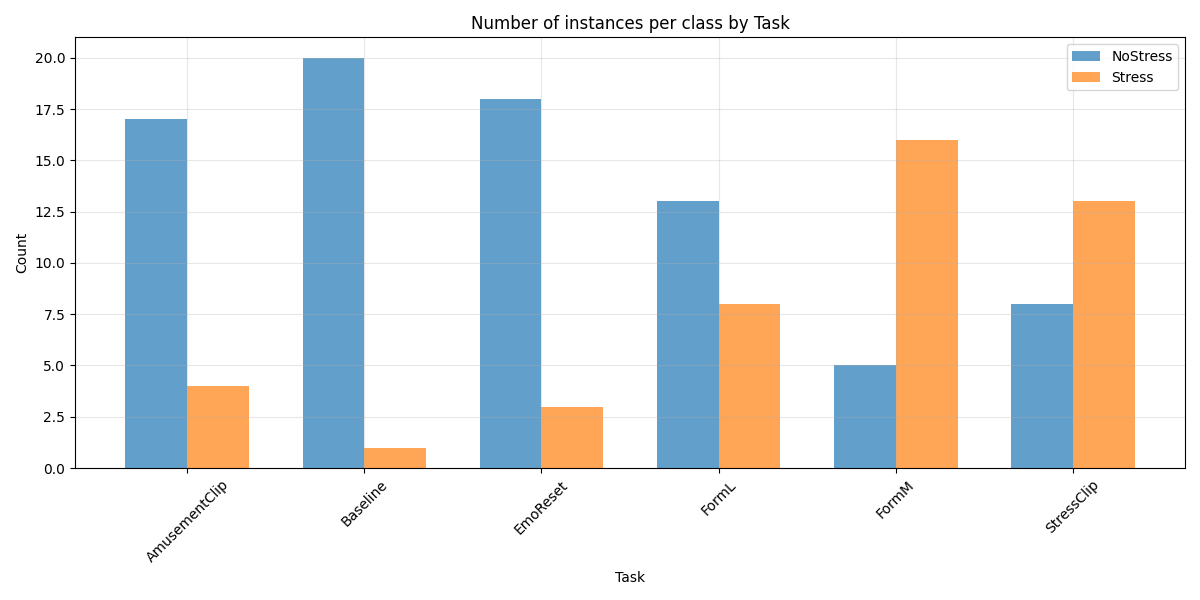


Instances count per task:


,NoStress,Stress
Task,,
AmusementClip,17,4
Baseline,20,1
EmoReset,18,3
FormL,13,8
FormM,5,16
StressClip,8,13


In [ ]:
stress_mask = [stress_file.split("-")[1] in STRESS_TASKS for stress_file in labels.index]
labels_stress = labels.loc[stress_mask]
frust_mask = [frust_file.split("-")[1] in FRUSTRATION_TASKS for frust_file in labels.index]
labels_frust = labels.loc[frust_mask]
print(f"Labels divided into {len(labels_stress)} stress tasks labels and {len(labels_frust)} frustration tasks labels")

x_stress = x.loc[stress_mask]
x_frust = x.loc[frust_mask]
print(f"Data divided into {len(x_stress)} stress tasks samples and {len(x_frust)} frustration tasks samples")

# Visualise class distribution
plt.figure(figsize=(12, 6))
y = labels["binary-stress"]
bin_stats = pd.DataFrame(
    {
        "Value": y.values,
        "Subject": [idx.split("-")[0] for idx in y.index],
        "Task": [idx.split("-")[1] for idx in y.index],
    },
    index=y.index,
)
for cls_id, cls_name in enumerate(BIN_LABELS):
    bin_stats[cls_name] = [value == cls_id for value in y]

tasks = sorted(bin_stats['Task'].unique())
x_positions = np.arange(len(tasks))
width = 0.35

# Plot bars and scatter points for each class
for i, class_name in enumerate(BIN_LABELS):
    counts = bin_stats.groupby('Task')[class_name].sum()
    bars = plt.bar(x_positions + (i-0.5)*width, [counts[task] for task in tasks], width,
                    label=class_name, alpha=0.7)

plt.xlabel('Task')
plt.ylabel('Count')
plt.title('Number of instances per class by Task')
plt.xticks(x_positions, tasks, rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nInstances count per task:")
display(bin_stats.groupby('Task')[BIN_LABELS].sum())


### Helper functions

In [6]:
def make_results_filename(classification: str, feature_selection: str | None) -> str:
    now = datetime.now()
    timestamp = now.strftime("%Y%m%d-%H%M%S")
    feature_selection = feature_selection if feature_selection is not None else "None"
    return f"{RESULTS_DIRECTORY}/{timestamp}_{classification}_{feature_selection}f"


def show_label_stats(labels: list[str], y: pd.Series):
    display(
        pd.DataFrame(
            {
                "labels": labels,
                "counts": y.value_counts().to_list(),
                "percentage": (y.value_counts(normalize=True) * 100).to_list(),
            }
        )
    )

def show_results(classification: str, feature_selector: str, results: pd.DataFrame, save=False):
    display(results)
    if save:
        res_file = make_results_filename(classification, feature_selector) + ".csv"
        print(f"Saving results to {res_file}")
        results.to_csv(res_file, sep=RESULTS_SEPARATOR)

def show_confusion_matrices(classification: str, feature_selector: str, conf_matrices: dict[str, np.ndarray], labels: list[int], save=False):
    cm_file = make_results_filename(classification, feature_selector) + ".CM.png"
    ncms = len(conf_matrices)
    pairs = [(name, cm) for name, cm in conf_matrices.items()]
    nrows = (ncms // 2) + (ncms % 2)
    fig, axes = plt.subplots(nrows, 2, figsize=(8, nrows * 4))
    for (name, cm), ax in zip(pairs, axes.ravel()):
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
        disp.plot(cmap=plt.cm.Blues, ax=ax, colorbar=False)
        ax.set_title(name)
    fig.suptitle("Confusion Matrices")
    plt.tight_layout()
    if save:
        print(f"Saving confusion matrix to {cm_file}")
        plt.savefig(cm_file, dpi=300, format="png")
    plt.show()



### Parameters

In [7]:
params = {
    "show_confusion_matrices": True,
    "save_confusion_matrices": False,
    "save_results": False,
    "verbose": False,
}

### Classification



============ binary ============


Stress tasks (videoclips)


,labels,counts,percentage
0,NoStress,45,71.428571
1,Stress,18,28.571429


,classifier,bal-accuracy,weighted-f1,macro-avg-prec,macro-avg-rec,macro-avg-f1,stress-prec,stress-rec,stress-f1
0,LogisticRegression,0.472222,0.485001,0.477181,0.472222,0.443347,0.264706,0.500000,0.346154
1,MLP,0.461111,0.515528,0.467857,0.461111,0.452174,0.250000,0.388889,0.304348
2,RandomForest,0.605556,0.709890,0.694318,0.605556,0.612308,0.625000,0.277778,0.384615
3,SVC,0.455556,0.563187,0.347458,0.455556,0.394231,0.000000,0.000000,0.000000


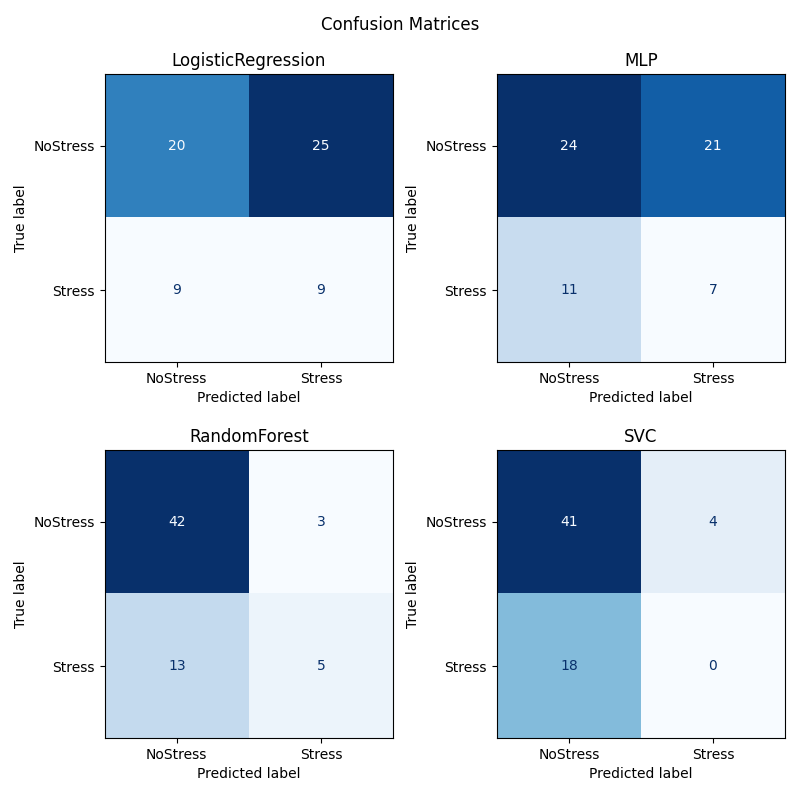


Frustration tasks (calculator)


,labels,counts,percentage
0,NoStress,36,57.142857
1,Stress,27,42.857143


/Users/sergio-de/Documents/Research/PhDCourse/UXFrustrationRecognition/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/sergio-de/Documents/Research/PhDCourse/UXFrustrationRecognition/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/sergio-de/Documents/Research/PhDCourse/UXFrustrationRecognition/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples

,classifier,bal-accuracy,weighted-f1,macro-avg-prec,macro-avg-rec,macro-avg-f1,stress-prec,stress-rec,stress-f1
0,LogisticRegression,0.435185,0.433204,0.408163,0.435185,0.403443,0.285714,0.148148,0.195122
1,MLP,0.407407,0.379365,0.314815,0.407407,0.338889,0.111111,0.037037,0.055556
2,RandomForest,0.500000,0.415584,0.285714,0.500000,0.363636,0.000000,0.000000,0.000000
3,SVC,0.500000,0.415584,0.285714,0.500000,0.363636,0.000000,0.000000,0.000000


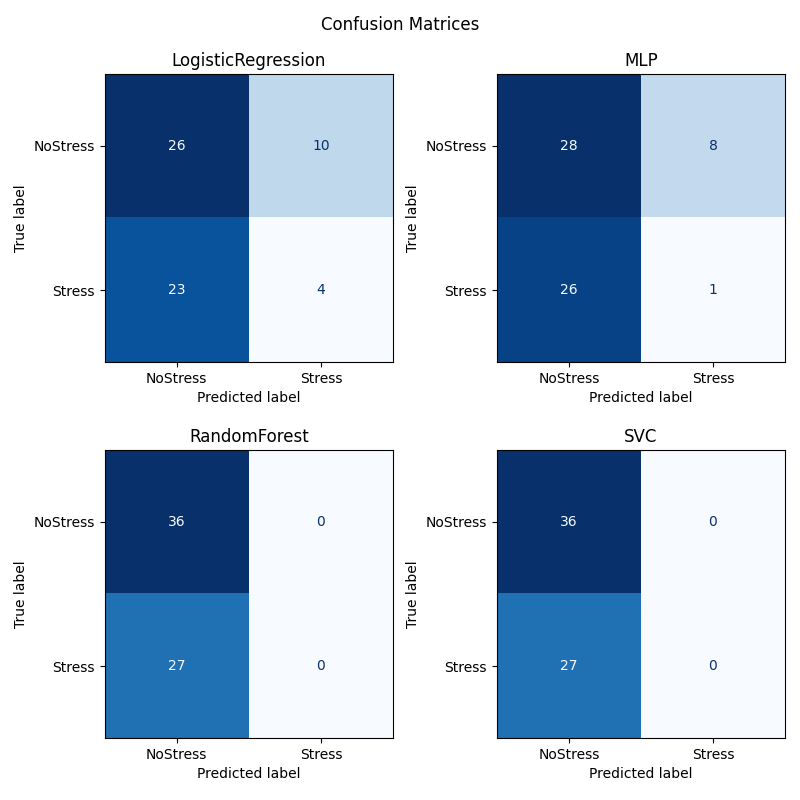



============ ternary ============


Stress tasks (videoclips)


,labels,counts,percentage
0,Relaxed,43,68.253968
1,Stress,13,20.634921
2,RealStress,7,11.111111


/Users/sergio-de/Documents/Research/PhDCourse/UXFrustrationRecognition/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/sergio-de/Documents/Research/PhDCourse/UXFrustrationRecognition/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/sergio-de/Documents/Research/PhDCourse/UXFrustrationRecognition/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples

,classifier,bal-accuracy,weighted-f1,macro-avg-prec,macro-avg-rec,macro-avg-f1,stress-prec,stress-rec,stress-f1
0,LogisticRegression,0.243036,0.139144,0.325641,0.243036,0.146638,0.076923,0.428571,0.130435
1,MLP,0.257603,0.410210,0.264436,0.257603,0.246847,0.000000,0.000000,0.000000
2,RandomForest,0.325581,0.551282,0.229508,0.325581,0.269231,0.000000,0.000000,0.000000
3,SVC,0.333333,0.553759,0.227513,0.333333,0.270440,0.000000,0.000000,0.000000


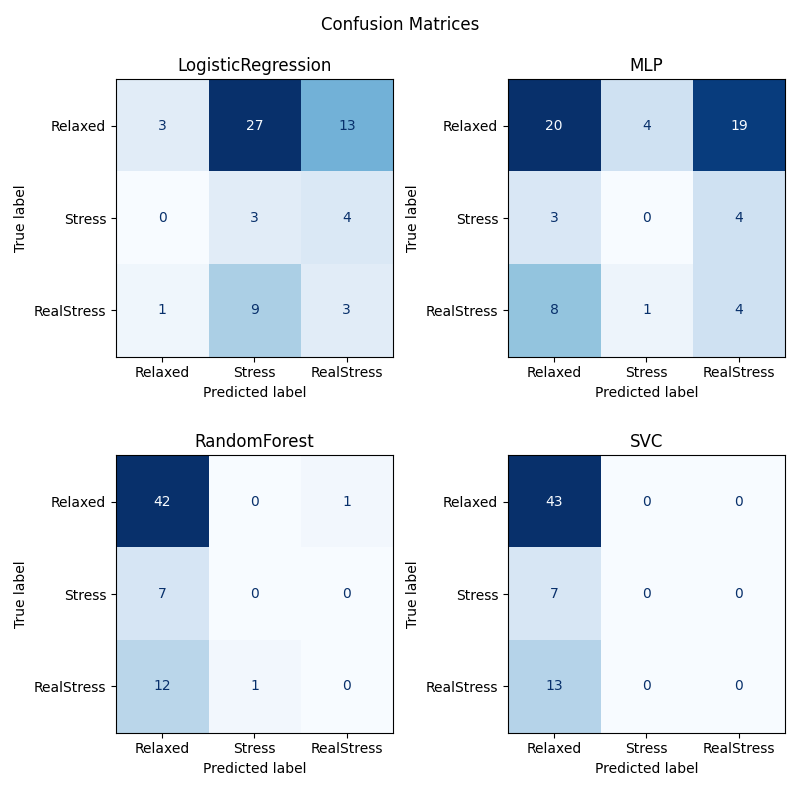


Frustration tasks (calculator)


,labels,counts,percentage
0,Relaxed,41,65.079365
1,Stress,15,23.809524
2,RealStress,7,11.111111


/Users/sergio-de/Documents/Research/PhDCourse/UXFrustrationRecognition/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/sergio-de/Documents/Research/PhDCourse/UXFrustrationRecognition/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/sergio-de/Documents/Research/PhDCourse/UXFrustrationRecognition/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples

,classifier,bal-accuracy,weighted-f1,macro-avg-prec,macro-avg-rec,macro-avg-f1,stress-prec,stress-rec,stress-f1
0,LogisticRegression,0.334495,0.188759,0.371795,0.334495,0.152903,0.115385,0.857143,0.20339
1,MLP,0.308401,0.489885,0.295175,0.308401,0.300654,0.000000,0.000000,0.00000
2,RandomForest,0.333333,0.513126,0.216931,0.333333,0.262821,0.000000,0.000000,0.00000
3,SVC,0.333333,0.518108,0.220430,0.333333,0.265372,0.000000,0.000000,0.00000


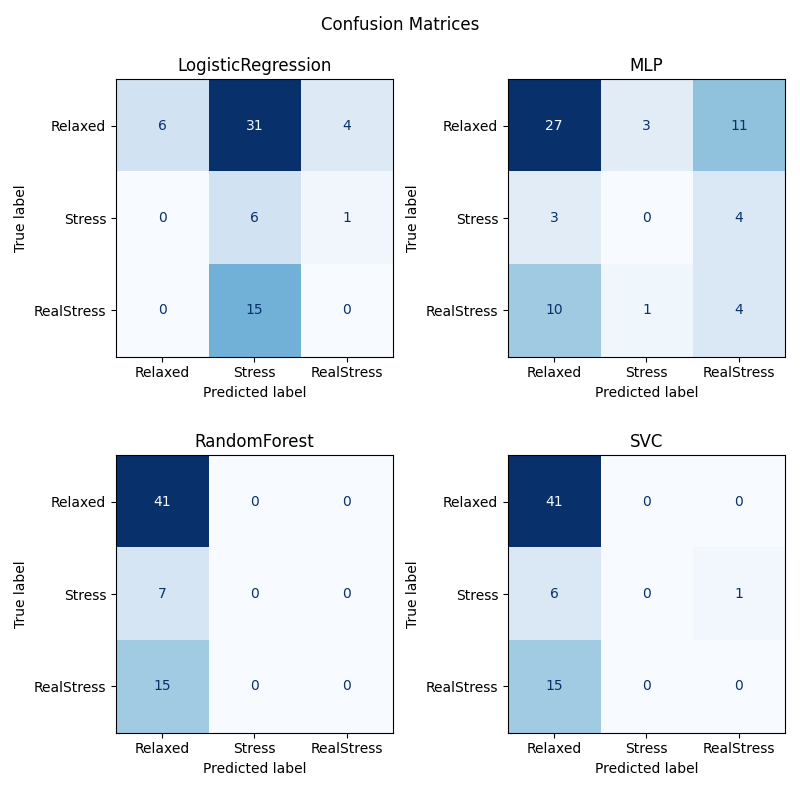



============ quaternary ============


Stress tasks (videoclips)


,labels,counts,percentage
0,Relaxed,35,55.555556
1,Stress,12,19.047619
2,RealStress,10,15.873016
3,Amused,6,9.523810


,classifier,bal-accuracy,weighted-f1,macro-avg-prec,macro-avg-rec,macro-avg-f1,stress-prec,stress-rec,stress-f1
0,LogisticRegression,0.263690,0.219484,0.248893,0.263690,0.169969,0.186047,0.8,0.301887
1,MLP,0.303571,0.441568,0.242599,0.303571,0.267387,0.312500,0.5,0.384615
2,RandomForest,0.308333,0.479289,0.548413,0.308333,0.313095,0.500000,0.1,0.166667
3,SVC,0.315476,0.107258,0.361111,0.315476,0.153818,0.333333,0.4,0.363636


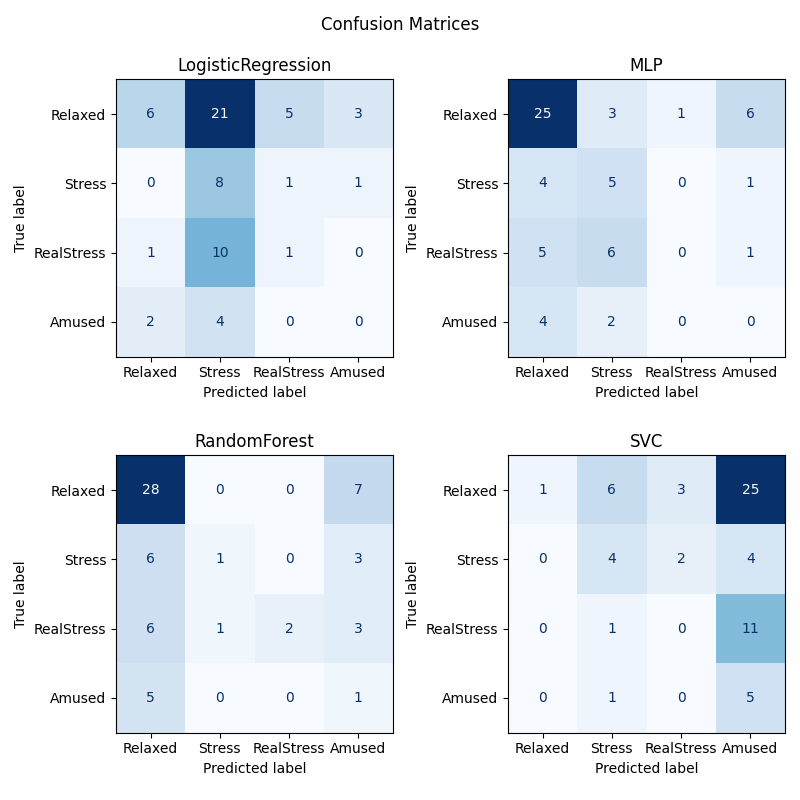


Frustration tasks (calculator)


,labels,counts,percentage
0,Relaxed,38,60.317460
1,Stress,13,20.634921
2,RealStress,9,14.285714
3,Amused,3,4.761905


/Users/sergio-de/Documents/Research/PhDCourse/UXFrustrationRecognition/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/sergio-de/Documents/Research/PhDCourse/UXFrustrationRecognition/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/sergio-de/Documents/Research/PhDCourse/UXFrustrationRecognition/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples

,classifier,bal-accuracy,weighted-f1,macro-avg-prec,macro-avg-rec,macro-avg-f1,stress-prec,stress-rec,stress-f1
0,LogisticRegression,0.110830,0.247840,0.152692,0.110830,0.120998,0.086957,0.153846,0.111111
1,MLP,0.203441,0.418021,0.184650,0.203441,0.189706,0.142857,0.076923,0.100000
2,RandomForest,0.230263,0.444444,0.153509,0.230263,0.184211,0.000000,0.000000,0.000000
3,SVC,0.250000,0.004762,0.013158,0.250000,0.025000,0.000000,0.000000,0.000000


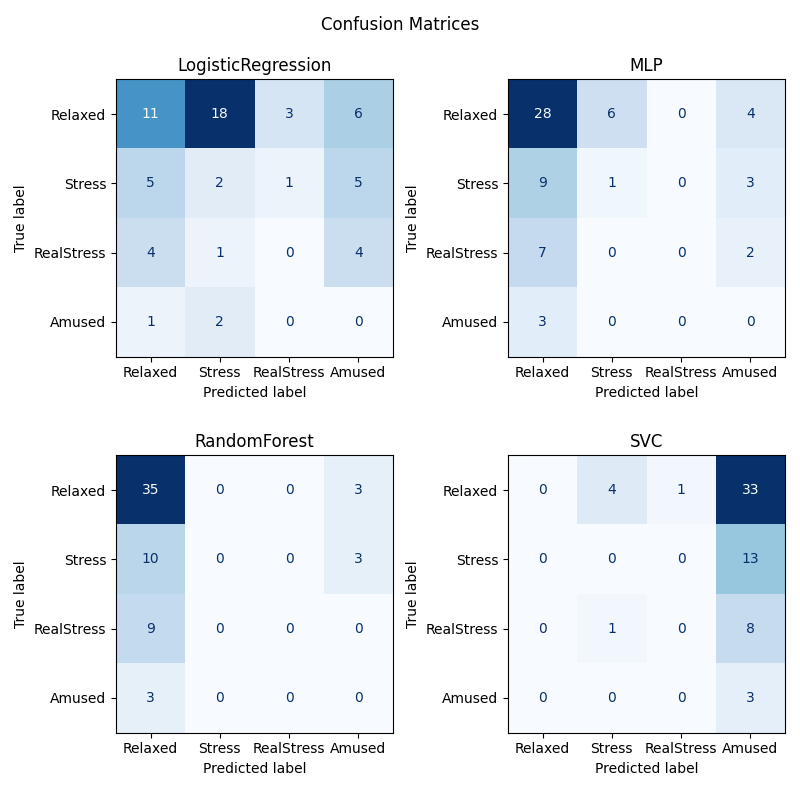

In [14]:
feat_sel = "RFE"
models_paths = {
    "b": {
        "LogisticRegression": f"{MODELS_PATH}/{MODELS_DATE}-143948_binary_LogisticRegression_{feat_sel}f.joblib",
        "MLP": f"{MODELS_PATH}/{MODELS_DATE}-143948_binary_MLPClassifier_{feat_sel}f.joblib",
        "RandomForest": f"{MODELS_PATH}/{MODELS_DATE}-143948_binary_RandomForestClassifier_{feat_sel}f.joblib",
        "SVC": f"{MODELS_PATH}/{MODELS_DATE}-143948_binary_SVC_{feat_sel}f.joblib",
    },
    "t": {
        "LogisticRegression": f"{MODELS_PATH}/{MODELS_DATE}-151743_ternary_LogisticRegression_{feat_sel}f.joblib",
        "MLP": f"{MODELS_PATH}/{MODELS_DATE}-151743_ternary_MLPClassifier_{feat_sel}f.joblib",
        "RandomForest": f"{MODELS_PATH}/{MODELS_DATE}-151743_ternary_RandomForestClassifier_{feat_sel}f.joblib",
        "SVC": f"{MODELS_PATH}/{MODELS_DATE}-151743_ternary_SVC_{feat_sel}f.joblib",
    },
    "q": {
        "LogisticRegression": f"{MODELS_PATH}/{MODELS_DATE}-154853_quaternary_LogisticRegression_{feat_sel}f.joblib",
        "MLP": f"{MODELS_PATH}/{MODELS_DATE}-154853_quaternary_MLPClassifier_{feat_sel}f.joblib",
        "RandomForest": f"{MODELS_PATH}/{MODELS_DATE}-154853_quaternary_RandomForestClassifier_{feat_sel}f.joblib",
        "SVC": f"{MODELS_PATH}/{MODELS_DATE}-154853_quaternary_SVC_{feat_sel}f.joblib",
    },
}
models: dict[str, dict[str, Pipeline]] = {}
for class_type, paths in models_paths.items():
    models[class_type] = {}
    for model_type, path in paths.items():
        models[class_type][model_type] = joblib.load(path)

for class_type, models in models.items():
    if class_type == "b":
        params["classification"] = "binary"
        params["classes"] = BIN_LABELS
        y_stress = labels_stress["binary-stress"]
        y_frust = labels_frust["binary-stress"]
    elif class_type == "t":
        params["classification"] = "ternary"
        params["classes"] = TER_LABELS
        y_stress = labels_stress["affect3-class"]
        y_frust = labels_frust["affect3-class"]
    elif class_type == "q":
        params["classification"] = "quaternary"
        params["classes"] = QAD_LABELS
        y_stress = labels_stress["affect4-class"]
        y_frust = labels_frust["affect4-class"]

    print(f"\n\n============ {params['classification']} ============\n\n")
    print("Stress tasks (videoclips)")
    show_label_stats(params["classes"], y_stress)

    df_res = pd.DataFrame(
        {
            "classifier": [],
            "bal-accuracy": [],
            "weighted-f1": [],
            "macro-avg-prec": [],
            "macro-avg-rec": [],
            "macro-avg-f1": [],
            "stress-prec": [],
            "stress-rec": [],
            "stress-f1": [],
        }
    )
    conf_matrices: dict[str, np.ndarray] = {}

    for model_name, model in models.items():
        y_pred = model.predict(x_stress)
        cm = confusion_matrix(y_stress, y_pred)
        report = classification_report(y_stress, y_pred, target_names=params["classes"], output_dict=True)
        conf_matrices[model_name] = cm

        s_report = report["Stress"]
        m_report = report["macro avg"]
        new_row = {
            "classifier": model_name,
            "bal-accuracy": balanced_accuracy_score(y_stress, y_pred),
            "weighted-f1": f1_score(y_stress, y_pred, average="weighted"),
            "macro-avg-prec": m_report["precision"],
            "macro-avg-rec": m_report["recall"],
            "macro-avg-f1": m_report["f1-score"],
            "stress-prec": s_report["precision"],
            "stress-rec": s_report["recall"],
            "stress-f1": s_report["f1-score"],
        }
        df_res.loc[len(df_res)] = new_row

    show_results(params["classification"] + " videoclips tasks", feat_sel, df_res, save=params["save_results"])
    if params["show_confusion_matrices"]:
        show_confusion_matrices(params["classification"], feat_sel, conf_matrices, labels=params["classes"], save=params["save_confusion_matrices"])

    print("\nFrustration tasks (calculator)")
    show_label_stats(params["classes"], y_frust)

    df_res = pd.DataFrame(
        {
            "classifier": [],
            "bal-accuracy": [],
            "weighted-f1": [],
            "macro-avg-prec": [],
            "macro-avg-rec": [],
            "macro-avg-f1": [],
            "stress-prec": [],
            "stress-rec": [],
            "stress-f1": [],
        }
    )
    conf_matrices: dict[str, np.ndarray] = {}

    for model_name, model in models.items():
        y_pred = model.predict(x_frust)
        cm = confusion_matrix(y_frust, y_pred)
        report = classification_report(y_frust, y_pred, target_names=params["classes"], output_dict=True)
        conf_matrices[model_name] = cm

        s_report = report["Stress"]
        m_report = report["macro avg"]
        new_row = {
            "classifier": model_name,
            "bal-accuracy": balanced_accuracy_score(y_frust, y_pred),
            "weighted-f1": f1_score(y_frust, y_pred, average="weighted"),
            "macro-avg-prec": m_report["precision"],
            "macro-avg-rec": m_report["recall"],
            "macro-avg-f1": m_report["f1-score"],
            "stress-prec": s_report["precision"],
            "stress-rec": s_report["recall"],
            "stress-f1": s_report["f1-score"],
        }
        df_res.loc[len(df_res)] = new_row

    show_results(params["classification"] + " calculator tasks", feat_sel, df_res, save=params["save_results"])
    if params["show_confusion_matrices"]:
        show_confusion_matrices(
            params["classification"],
            feat_sel,
            conf_matrices,
            labels=params["classes"],
            save=params["save_confusion_matrices"],
        )